# 4BBBB — Fixed Combined Thermal + Raw-State Multi-Temperature Analysis

This is the fixed-analysis companion to **4AAAA**. It performs no hyperparameter
optimization. It loads the single configuration selected by 4AAAA and reproduces
the same regressor inputs in every evaluation fold:

- operating temperature;
- manually computed scalar thermal features; and
- raw ESN states on the ordered 11-point 0–1 s grid.

The notebook evaluates that fixed configuration with LORO, LOMO, and LOTO and
reports pooled metrics, valid fold diagnostics, and actual-versus-predicted plots.


# 1. Imports and experiment configuration


In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import linalg
from scipy.signal import savgol_filter
from scipy.stats import kurtosis, skew
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

#


In [2]:
TEMPERATURE_FOLDERS = ("30C", "40C", "50C", "60C")
PARAMETER_TARGET = "eff"
RANDOM_STATE = 42

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((path for path in (cwd, cwd.parent) if (path / "data").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")
DATA_ROOT = PROJECT_ROOT / "data" / "02_preprocessed"
RESULTS_DIR = PROJECT_ROOT / "results" / "multi_temp_esn"
temperature_tag = "-".join(TEMPERATURE_FOLDERS)
PARAMETER_FILE = RESULTS_DIR / (
    f"{temperature_tag}_{PARAMETER_TARGET}"
    "_v8_4aaaa_raw_states_0to1_optuna_tpe_mlflow_parameters.json"
)
RESULT_STEM = f"{temperature_tag}_{PARAMETER_TARGET}_4bbbb_fixed_combined_raw_states"
if not PARAMETER_FILE.is_file():
    raise FileNotFoundError(f"Missing {PARAMETER_FILE}\nRun Notebook 4AAAA first.")

with PARAMETER_FILE.open() as file:
    SAVED_CONFIGURATION = json.load(file)
if tuple(SAVED_CONFIGURATION["temperature_folders"]) != TEMPERATURE_FOLDERS:
    raise ValueError("Saved temperature folders do not match TEMPERATURE_FOLDERS.")
if SAVED_CONFIGURATION["target"] != PARAMETER_TARGET:
    raise ValueError("Saved target does not match PARAMETER_TARGET.")

ANALYSIS_WINDOW = tuple(SAVED_CONFIGURATION["analysis_window"])
if ANALYSIS_WINDOW != (0.0, 1.0):
    raise ValueError(f"4BBBB requires analysis_window=(0.0, 1.0), got {ANALYSIS_WINDOW}.")
EARLY_WINDOW = tuple(SAVED_CONFIGURATION["thermal_windows"]["early"])
MID_WINDOW = tuple(SAVED_CONFIGURATION["thermal_windows"]["mid"])
LATE_WINDOW = tuple(SAVED_CONFIGURATION["thermal_windows"]["late"])

representation = SAVED_CONFIGURATION.get("reservoir_representation", {})
if representation.get("type") != "raw_time_ordered_states":
    raise ValueError("Parameter file does not contain 4AAAA raw-state provenance.")
if representation.get("statistical_summaries_used") is not False:
    raise ValueError("4BBBB requires unsummarized raw reservoir states.")
RAW_STATE_TIME_POINTS = int(representation["time_points"])

expected_blocks = {
    "Temperature_C", "manual_scalar_thermal_features", "raw_ESN_states"
}
if set(SAVED_CONFIGURATION.get("regressor_input_blocks", [])) != expected_blocks:
    raise ValueError("Saved regressor-input blocks do not match the 4BBBB pipeline.")

ESN_PARAMETERS = SAVED_CONFIGURATION["esn_parameters"]
ESN_RES_SIZE = int(ESN_PARAMETERS["res_size"])
ESN_LEAK_RATE = float(ESN_PARAMETERS["leak_rate"])
ESN_INPUT_MAGNITUDE = float(ESN_PARAMETERS["input_magnitude"])
ESN_SPECTRAL_RADIUS = float(ESN_PARAMETERS["spectral_radius"])
ESN_WASHOUT = int(ESN_PARAMETERS["washout"])
if ESN_WASHOUT != 0:
    raise ValueError(f"4BBBB requires washout=0, got {ESN_WASHOUT}.")
if ESN_RES_SIZE > 30:
    raise ValueError(f"Unexpected reservoir size above 30: {ESN_RES_SIZE}.")

XGB_PARAMS = SAVED_CONFIGURATION["xgb_parameters"]
RESERVOIR_SEEDS = tuple(int(seed) for seed in SAVED_CONFIGURATION["reservoir_seeds"])
REGRESSION_TARGETS = (PARAMETER_TARGET,)

print("Loaded:", PARAMETER_FILE)
print("Analysis window:", ANALYSIS_WINDOW)
print("Raw-state time points:", RAW_STATE_TIME_POINTS)
print("ESN parameters:", ESN_PARAMETERS)
print("XGBoost parameters:", XGB_PARAMS)
print("Reservoir seeds:", RESERVOIR_SEEDS)


Loaded: /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/multi_temp_esn/30C-40C-50C-60C_eff_v8_4aaaa_raw_states_0to1_optuna_tpe_mlflow_parameters.json
Analysis window: (0.0, 1.0)
Raw-state time points: 11
ESN parameters: {'res_size': 11, 'leak_rate': 0.2278420823756697, 'input_magnitude': 0.5452250913367468, 'spectral_radius': 0.3625215829868904, 'washout': 0}
XGBoost parameters: {'n_estimators': 1101, 'max_depth': 2, 'learning_rate': 0.1326097065459352, 'min_child_weight': 8.141832764065489, 'subsample': 0.9430576972687108, 'colsample_bytree': 0.6053473823373768, 'reg_alpha': 0.0001190179149463, 'reg_lambda': 0.0116222014830349}
Reservoir seeds: (42, 43, 44)


# 2. Standard material properties and trial loading

The processed CSV values in `k`, `Mass`, `Volume`, `rho`, and `cp` are deliberately
ignored. After loading the sensor data, the notebook overwrites those fields using
the authoritative table below.

`Mass=1 kg` and `Volume=1 m³` are placeholders and can be updated later.


In [3]:
STANDARD_PROPERTIES = {
    "ps_foam":   {"k": 0.034, "Mass": 1.0, "Volume": 1.0, "rho": 25.0,   "cp": 1400.0},
    "pu_foam":   {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 30.0,   "cp": 1400.0},
    "cork":      {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 240.0,  "cp": 1800.0},
    "wood":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 700.0,  "cp": 1700.0},
    "pdms":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 970.0,  "cp": 1460.0},
    "gypsum":    {"k": 0.170, "Mass": 1.0, "Volume": 1.0, "rho": 800.0,  "cp": 1090.0},
    "cement":    {"k": 0.290, "Mass": 1.0, "Volume": 1.0, "rho": 1440.0, "cp": 750.0},
    "graphite":  {"k": 100.0, "Mass": 1.0, "Volume": 1.0, "rho": 1820.0, "cp": 710.0},
    "bismuth":   {"k": 8.1,   "Mass": 1.0, "Volume": 1.0, "rho": 9780.0, "cp": 130.0},
    "titanium":  {"k": 21.9,  "Mass": 1.0, "Volume": 1.0, "rho": 4506.0, "cp": 523.0},
    "nickel":    {"k": 90.9,  "Mass": 1.0, "Volume": 1.0, "rho": 8908.0, "cp": 461.0},
    "iron":      {"k": 80.4,  "Mass": 1.0, "Volume": 1.0, "rho": 7874.0, "cp": 449.0},
    "aluminum":  {"k": 237.0, "Mass": 1.0, "Volume": 1.0, "rho": 2700.0, "cp": 897.0},
    "copper":    {"k": 401.0, "Mass": 1.0, "Volume": 1.0, "rho": 8960.0, "cp": 385.0},
}

SAMPLE_ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood",
    "pdms": "pdms",
    "gypsum": "gypsum",
    "cement": "cement",
    "graphite": "graphite", "carbon": "graphite",
    "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium",
    "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron",
    "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

standard_table = (
    pd.DataFrame.from_dict(STANDARD_PROPERTIES, orient="index")
    .rename_axis("Material")
    .reset_index()
)
display(standard_table)

required = {"Sample", "Trial", "Time", "Primary", "Secondary"}
frames = []
load_rows = []

for temperature in TEMPERATURE_FOLDERS:
    folder = DATA_ROOT / temperature
    for path in sorted(folder.glob("*.csv")):
        frame = pd.read_csv(path)
        missing = required - set(frame.columns)
        if missing:
            warnings.warn(
                f"Skipping {temperature}/{path.name}; missing {sorted(missing)}"
            )
            continue
        frame["Temperature"] = temperature
        frame["source_file"] = path.name
        frames.append(frame)
        load_rows.append({
            "Temperature": temperature,
            "file": path.name,
            "rows_loaded": len(frame),
        })

if not frames:
    raise ValueError("No valid trial files were found.")

DATA = pd.concat(frames, ignore_index=True)
DATA = DATA.replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary", "Secondary"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required) + ["Temperature"]).copy()
DATA["Trial"] = DATA["Trial"].astype(int)
DATA["Temperature_C"] = pd.to_numeric(
    DATA["Temperature"].str.extract(r"(\d+(?:\.\d+)?)", expand=False),
    errors="coerce",
)
if DATA["Temperature_C"].isna().any():
    raise ValueError("A temperature-folder name could not be converted to Celsius.")

normalized_sample = (
    DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
)
DATA["Sample"] = normalized_sample.map(SAMPLE_ALIASES)
unknown_mask = DATA["Sample"].isna()
if unknown_mask.any():
    unknown = sorted(normalized_sample[unknown_mask].unique())
    raise KeyError(f"No standard-property mapping for samples: {unknown}")

# Ignore processed-file property cells and apply one standard table everywhere.
for property_name in ("k", "Mass", "Volume", "rho", "cp"):
    DATA[property_name] = DATA["Sample"].map(
        lambda sample: STANDARD_PROPERTIES[sample][property_name]
    )

# Temperature is required in the ID because material/trial numbers repeat by folder.
DATA["trial_id"] = (
    DATA["Temperature"].astype(str)
    + "__" + DATA["Sample"].astype(str)
    + "_trial_" + DATA["Trial"].astype(str)
)
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA = DATA.sort_values(["Temperature", "trial_id", "Time"]).reset_index(drop=True)

summary = (
    DATA.groupby(["trial_id", "Temperature", "Sample", "Trial"], as_index=False)
    .agg(
        n_timesteps=("Time", "size"),
        k=("k", "first"),
        eff=("eff", "first"),
    )
)
temperature_summary = (
    summary.groupby("Temperature", as_index=False)
    .agg(
        trials=("trial_id", "nunique"),
        materials=("Sample", "nunique"),
        minimum_timesteps=("n_timesteps", "min"),
        maximum_timesteps=("n_timesteps", "max"),
    )
)
print(f"Rows: {len(DATA):,}")
print(f"Unique temperature-specific trials: {DATA['trial_id'].nunique()}")
display(temperature_summary)


,Material,k,Mass,Volume,rho,cp
0,ps_foam,0.034,1.0,1.0,25.0,1400.0
1,pu_foam,0.043,1.0,1.0,30.0,1400.0
2,cork,0.043,1.0,1.0,240.0,1800.0
3,wood,0.150,1.0,1.0,700.0,1700.0
4,pdms,0.150,1.0,1.0,970.0,1460.0
5,gypsum,0.170,1.0,1.0,800.0,1090.0
6,cement,0.290,1.0,1.0,1440.0,750.0
7,graphite,100.000,1.0,1.0,1820.0,710.0
8,bismuth,8.100,1.0,1.0,9780.0,130.0
9,titanium,21.900,1.0,1.0,4506.0,523.0


Rows: 70,480
Unique temperature-specific trials: 336


,Temperature,trials,materials,minimum_timesteps,maximum_timesteps
0,30C,84,14,184,227
1,40C,84,14,200,362
2,50C,84,14,183,404
3,60C,84,14,186,326


# 3. Detect contact and align every trial

The elbow is used only to establish a common time origin. Prediction uses the fixed
0–1 second response after contact. Trials are never aligned using `k` or `eff`.


In [4]:
def find_contact_time(
    trial,
    smooth_window=15,
    polyorder=2,
    threshold_frac=0.30,
    skip_samples=5,
):
    clean = (
        trial[["Time", "Primary"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
        .sort_values("Time")
        .drop_duplicates("Time")
        .reset_index(drop=True)
    )
    time = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time) <= 0):
        raise ValueError("Insufficient or invalid time samples.")

    work_time = time[skip_samples:]
    work_signal = signal[skip_samples:]
    window = min(int(smooth_window), len(work_signal))
    if window % 2 == 0:
        window -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    if window < minimum:
        raise ValueError("Sequence is too short for smoothing.")

    smooth = savgol_filter(work_signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, work_time)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(work_time[elbow])


In [5]:
aligned_trials = {}
alignment_rows = []

for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact_time = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue

    trial["time_from_contact"] = trial["Time"] - contact_time
    start, end = ANALYSIS_WINDOW
    trial = trial[
        trial["time_from_contact"].between(start, end, inclusive="both")
    ].copy()
    if len(trial) < 10:
        warnings.warn(f"Skipping {trial_id}: too few post-contact samples")
        continue
    aligned_trials[trial_id] = trial.reset_index(drop=True)
    alignment_rows.append({
        "trial_id": trial_id,
        "Temperature": trial["Temperature"].iloc[0],
        "Temperature_C": float(trial["Temperature_C"].iloc[0]),
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "contact_time": contact_time,
        "n_analysis_samples": len(trial),
    })

ALIGNMENT = pd.DataFrame(alignment_rows)
print(f"Aligned trials retained: {len(aligned_trials)}")
display(ALIGNMENT.head())


Aligned trials retained: 336


,trial_id,Temperature,Temperature_C,Sample,Trial,contact_time,n_analysis_samples
0,30C__aluminum_trial_1,30C,30.0,aluminum,1,8.40066,11
1,30C__aluminum_trial_2,30C,30.0,aluminum,2,7.40070,11
2,30C__aluminum_trial_3,30C,30.0,aluminum,3,7.70070,11
3,30C__aluminum_trial_4,30C,30.0,aluminum,4,8.70070,11
4,30C__aluminum_trial_5,30C,30.0,aluminum,5,7.20070,11


## Check several alignments visually


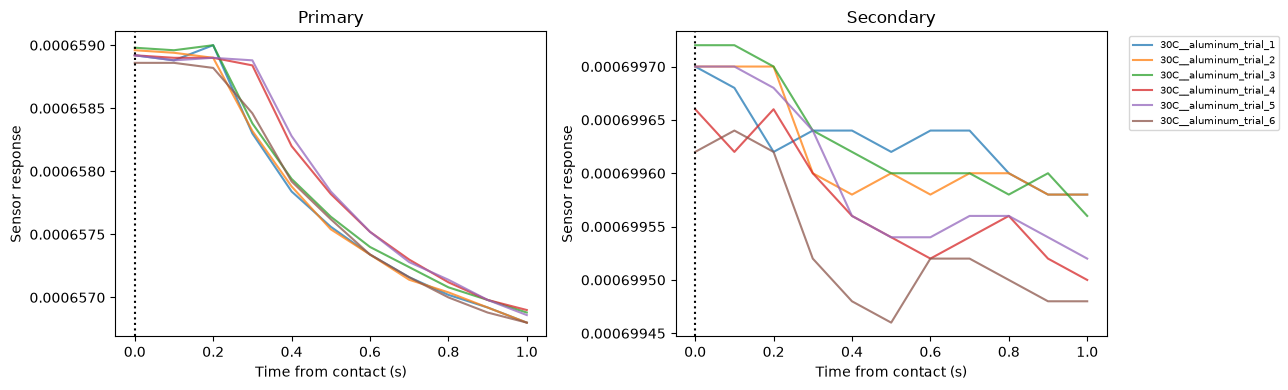

In [6]:
def plot_aligned_trials(material=None, maximum_trials=6):
    selected = list(aligned_trials.values())
    if material is not None:
        selected = [x for x in selected if x["Sample"].iloc[0] == material]
    selected = selected[:maximum_trials]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
    for trial in selected:
        label = trial["trial_id"].iloc[0]
        axes[0].plot(trial["time_from_contact"], trial["Primary"], alpha=0.75, label=label)
        axes[1].plot(trial["time_from_contact"], trial["Secondary"], alpha=0.75, label=label)
    for ax, title in zip(axes, ["Primary", "Secondary"]):
        ax.axvline(0, color="black", linestyle=":")
        ax.set(xlabel="Time from contact (s)", ylabel="Sensor response", title=title)
    axes[1].legend(fontsize=7, bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_aligned_trials(material=ALIGNMENT["Sample"].iloc[0])


# 4. Interpretable thermal-response features


In [7]:
def _smooth(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0:
        selected -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    return (
        savgol_filter(values, selected, polyorder, mode="interp")
        if selected >= minimum else values.copy()
    )


def _slope(time, values, window):
    mask = (time >= window[0]) & (time <= window[1])
    if mask.sum() < 3:
        return np.nan
    return float(np.polyfit(time[mask], values[mask], 1)[0])


def extract_thermal_features(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    secondary = _smooth(trial["Secondary"].to_numpy(float))
    difference = primary - secondary
    result = {}

    for name, signal in {
        "primary": primary,
        "secondary": secondary,
        "difference": difference,
    }.items():
        change = signal - signal[0]
        rate = np.gradient(signal, time)
        result[f"{name}_final_change"] = float(change[-1])
        result[f"{name}_max_abs_change"] = float(np.max(np.abs(change)))
        result[f"{name}_response_auc"] = float(np.trapezoid(np.abs(change), time))
        result[f"{name}_early_slope"] = _slope(time, signal, EARLY_WINDOW)
        result[f"{name}_mid_slope"] = _slope(time, signal, MID_WINDOW)
        result[f"{name}_late_slope"] = _slope(time, signal, LATE_WINDOW)
        result[f"{name}_max_abs_rate"] = float(np.max(np.abs(rate)))
        result[f"{name}_rate_auc"] = float(np.trapezoid(np.abs(rate), time))

    # Dimensionless/cross-sensor summaries.
    primary_auc = result["primary_response_auc"]
    result["secondary_primary_auc_ratio"] = (
        result["secondary_response_auc"] / primary_auc
        if not np.isclose(primary_auc, 0) else np.nan
    )
    result["initial_sensor_difference"] = float(difference[0])
    result["final_sensor_difference"] = float(difference[-1])
    return result


thermal_rows = []
for trial_id, trial in aligned_trials.items():
    features = extract_thermal_features(trial)
    features.update({
        "trial_id": trial_id,
        "Temperature": trial["Temperature"].iloc[0],
        "Temperature_C": float(trial["Temperature_C"].iloc[0]),
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "k": float(trial["k"].iloc[0]),
        "eff": float(trial["eff"].iloc[0]),
    })
    thermal_rows.append(features)

THERMAL_FEATURES = pd.DataFrame(thermal_rows)
print(f"Thermal features: {len(THERMAL_FEATURES.columns) - 7}")
display(THERMAL_FEATURES.head())


Thermal features: 27


,primary_final_change,primary_max_abs_change,primary_response_auc,primary_early_slope,primary_mid_slope,primary_late_slope,primary_max_abs_rate,primary_rate_auc,secondary_final_change,secondary_max_abs_change,...,secondary_primary_auc_ratio,initial_sensor_difference,final_sensor_difference,trial_id,Temperature,Temperature_C,Sample,Trial,k,eff
0,-0.000002,0.000002,0.000001,-0.000003,-0.000003,-0.000002,0.000003,0.000002,-9.636364e-08,9.636364e-08,...,0.035848,-0.000040,-0.000043,30C__aluminum_trial_1,30C,30.0,aluminum,1,237.0,23958.094665
1,-0.000002,0.000002,0.000001,-0.000003,-0.000003,-0.000002,0.000004,0.000002,-1.254545e-07,1.365408e-07,...,0.069221,-0.000040,-0.000043,30C__aluminum_trial_2,30C,30.0,aluminum,2,237.0,23958.094665
2,-0.000002,0.000002,0.000001,-0.000003,NaN,-0.000002,0.000003,0.000002,-1.581818e-07,1.581818e-07,...,0.075689,-0.000040,-0.000043,30C__aluminum_trial_3,30C,30.0,aluminum,3,237.0,23958.094665
3,-0.000002,0.000002,0.000001,-0.000002,-0.000002,-0.000002,0.000002,0.000002,-1.509091e-07,1.509091e-07,...,0.078391,-0.000040,-0.000043,30C__aluminum_trial_4,30C,30.0,aluminum,4,237.0,23958.094665
4,-0.000002,0.000002,0.000001,-0.000002,-0.000002,-0.000003,0.000003,0.000002,-1.890909e-07,1.911608e-07,...,0.110824,-0.000041,-0.000043,30C__aluminum_trial_5,30C,30.0,aluminum,5,237.0,23958.094665


# 5. Manual ESN reservoir with raw time-ordered states

No reservoir trajectory summaries are calculated. Every trial is interpolated to
the same 11-point 0–1 s grid, and its raw state matrix is flattened in time-major
order, exactly as in 4AAAA.


In [8]:
class ManualReservoir:
    def __init__(
        self,
        res_size=30,
        leak_rate=0.9,
        input_magnitude=1.5,
        spectral_radius=1.3,
        washout=0,
        random_state=42,
    ):
        self.res_size = int(res_size)
        self.leak_rate = float(leak_rate)
        self.input_magnitude = float(input_magnitude)
        self.spectral_radius = float(spectral_radius)
        self.washout = int(washout)
        rng = np.random.default_rng(random_state)
        self.Win = (rng.random((self.res_size, 1 + 5)) - 0.5) * self.input_magnitude
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        if not np.isfinite(radius) or np.isclose(radius, 0):
            raise ValueError("Invalid reservoir spectral radius.")
        self.W = (W / radius.real) * self.spectral_radius

    def run(self, sequence):
        sequence = np.asarray(sequence, float)
        if sequence.ndim != 2 or sequence.shape[1] != 5:
            raise ValueError("Expected sequence with five input channels.")
        if len(sequence) <= self.washout:
            raise ValueError(
                f"Sequence has {len(sequence)} samples, but washout={self.washout}. "
                "Washout must be smaller than the sequence length."
            )
        x = np.zeros((self.res_size, 1))
        states = []
        for row in sequence:
            u = row.reshape(-1, 1)
            x = (
                (1 - self.leak_rate) * x
                + self.leak_rate * np.tanh(
                    self.Win @ np.vstack((1.0, u)) + self.W @ x
                )
            )
            states.append(x[:, 0].copy())
        return np.asarray(states)[self.washout:]


def raw_esn_input(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    secondary = _smooth(trial["Secondary"].to_numpy(float))
    difference = primary - secondary
    primary_rate = np.gradient(primary, time)
    secondary_rate = np.gradient(secondary, time)
    return np.column_stack([
        primary, secondary, difference, primary_rate, secondary_rate
    ])


def flatten_raw_reservoir_states(time, states):
    """Interpolate raw states to the saved fixed grid and preserve time order."""
    time = np.asarray(time, float)
    states = np.asarray(states, float)
    if states.ndim != 2 or len(time) != len(states):
        raise ValueError("Time and reservoir states must have matching rows.")
    if len(time) < 2 or np.any(~np.isfinite(time)) or np.any(np.diff(time) <= 0):
        raise ValueError("Reservoir-state time must be finite and strictly increasing.")
    if np.any(~np.isfinite(states)):
        raise ValueError("Reservoir states contain non-finite values.")

    fixed_time = np.linspace(
        ANALYSIS_WINDOW[0], ANALYSIS_WINDOW[1], RAW_STATE_TIME_POINTS
    )
    interpolated = np.column_stack([
        np.interp(fixed_time, time, states[:, unit])
        for unit in range(states.shape[1])
    ])
    return {
        f"esn_state_t{time_index:03d}_u{unit:03d}": float(
            interpolated[time_index, unit]
        )
        for time_index in range(interpolated.shape[0])
        for unit in range(interpolated.shape[1])
    }


# 6. Visualize ESN state evolution

This section shows how the reservoir responds through the 0–5 second post-contact
window. The visualization uses the same reservoir hyperparameters as regression.

The scaler below is fitted across all trials **only for descriptive visualization**.
It is not reused by cross-validation; evaluation continues to fit scaling exclusively
inside each outer training fold.


In [9]:
def compute_visualization_states(trial_id):
    if trial_id not in aligned_trials:
        raise KeyError(trial_id)

    # Descriptive scaler only—never passed into the evaluation engine.
    visualization_scaler = StandardScaler().fit(np.vstack([
        raw_esn_input(trial) for trial in aligned_trials.values()
    ]))
    reservoir = ManualReservoir(
        res_size=ESN_RES_SIZE,
        leak_rate=ESN_LEAK_RATE,
        input_magnitude=ESN_INPUT_MAGNITUDE,
        spectral_radius=ESN_SPECTRAL_RADIUS,
        washout=ESN_WASHOUT,
        random_state=RANDOM_STATE,
    )
    trial = aligned_trials[trial_id]
    scaled_sequence = visualization_scaler.transform(raw_esn_input(trial))
    states = reservoir.run(scaled_sequence)
    time = trial["time_from_contact"].to_numpy(float)[ESN_WASHOUT:]
    return trial, time, scaled_sequence[ESN_WASHOUT:], states


SELECTED_TRIAL_ID = ALIGNMENT["trial_id"].iloc[0]
selected_trial, state_time, selected_inputs, selected_states = (
    compute_visualization_states(SELECTED_TRIAL_ID)
)

print("Selected trial:", SELECTED_TRIAL_ID)
print("Reservoir-state matrix:", selected_states.shape)


Selected trial: 30C__aluminum_trial_1
Reservoir-state matrix: (11, 11)


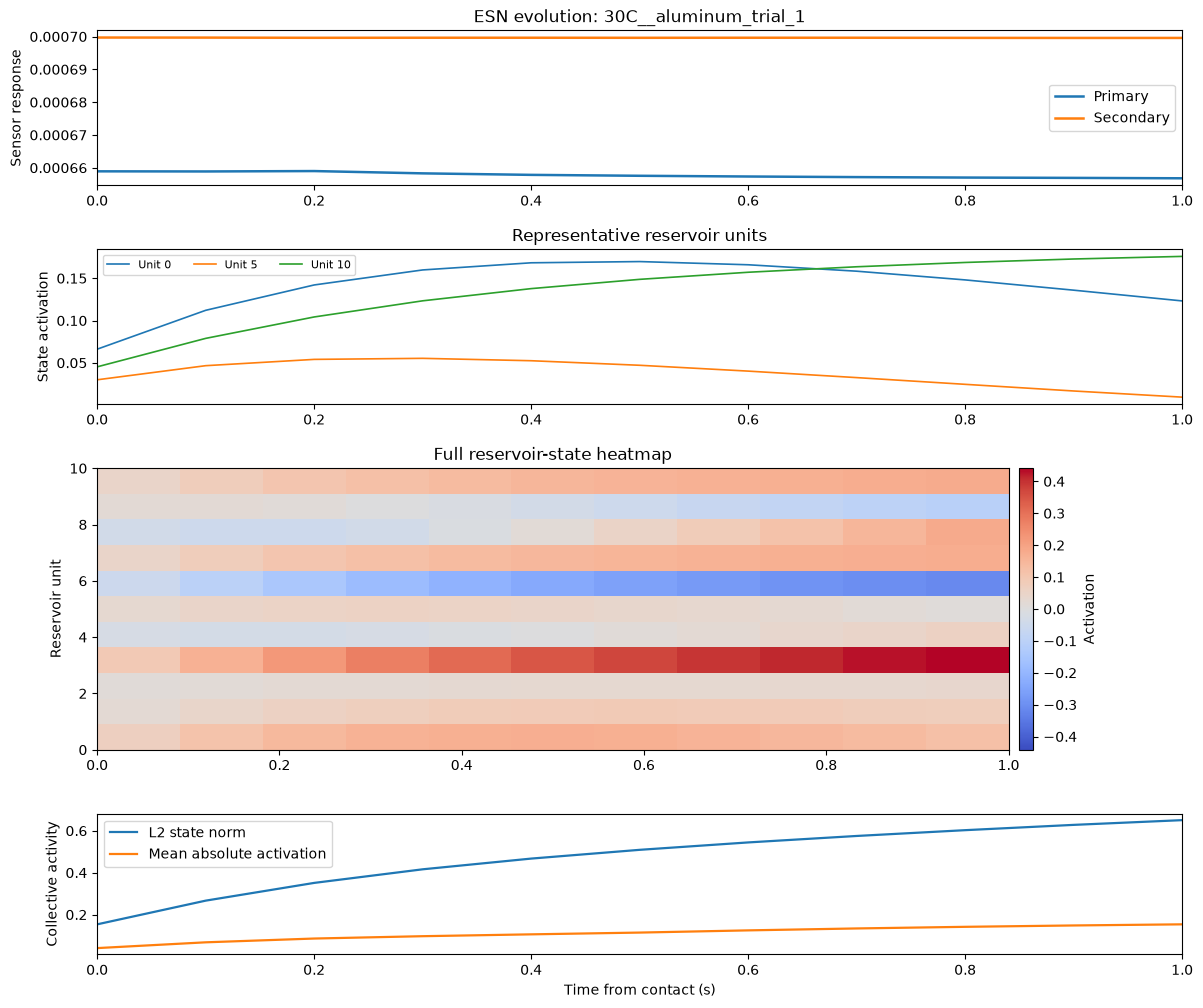

In [10]:
def plot_esn_dynamics(trial_id=SELECTED_TRIAL_ID, units_to_plot=(0, 5, 10, 15, 20, 25)):
    trial, time, scaled_inputs, states = compute_visualization_states(trial_id)

    fig = plt.figure(figsize=(14, 12))
    grid = fig.add_gridspec(4, 1, height_ratios=[1.1, 1.1, 2.0, 1.0], hspace=0.35)

    # Raw sensor response
    ax_inputs = fig.add_subplot(grid[0])
    ax_inputs.plot(
        trial["time_from_contact"], trial["Primary"],
        label="Primary", linewidth=1.8,
    )
    ax_inputs.plot(
        trial["time_from_contact"], trial["Secondary"],
        label="Secondary", linewidth=1.8,
    )
    ax_inputs.set(ylabel="Sensor response", title=f"ESN evolution: {trial_id}")
    ax_inputs.legend(loc="best")

    # Representative reservoir units
    ax_units = fig.add_subplot(grid[1], sharex=ax_inputs)
    valid_units = [unit for unit in units_to_plot if unit < states.shape[1]]
    for unit in valid_units:
        ax_units.plot(time, states[:, unit], label=f"Unit {unit}", linewidth=1.2)
    ax_units.set(ylabel="State activation", title="Representative reservoir units")
    ax_units.legend(ncol=3, fontsize=8)

    # Full state heatmap
    ax_heatmap = fig.add_subplot(grid[2], sharex=ax_inputs)
    limit = np.max(np.abs(states))
    image = ax_heatmap.imshow(
        states.T,
        aspect="auto",
        origin="lower",
        extent=[time.min(), time.max(), 0, states.shape[1] - 1],
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit,
        interpolation="nearest",
    )
    ax_heatmap.set(ylabel="Reservoir unit", title="Full reservoir-state heatmap")
    fig.colorbar(image, ax=ax_heatmap, label="Activation", pad=0.01)

    # Collective reservoir activity
    ax_norm = fig.add_subplot(grid[3], sharex=ax_inputs)
    state_norm = np.linalg.norm(states, axis=1)
    mean_abs_state = np.mean(np.abs(states), axis=1)
    ax_norm.plot(time, state_norm, label="L2 state norm", linewidth=1.6)
    ax_norm.plot(time, mean_abs_state, label="Mean absolute activation", linewidth=1.6)
    ax_norm.set(xlabel="Time from contact (s)", ylabel="Collective activity")
    ax_norm.legend(loc="best")

    plt.show()


plot_esn_dynamics()


## How to interpret the dynamics

- Each heatmap row is one reservoir unit and each column is a post-contact timestep.
- Alternating red and blue patterns show nonlinear units responding with different signs.
- Persistent bands indicate memory of earlier sensor behavior.
- Rapid changes shortly after contact show the reservoir encoding the transient response.
- The state norm summarizes the strength of collective reservoir activation.
- These states are not predictions by themselves; their trajectory summaries become the ESN regression features.


# 7. Leakage-safe fixed-parameter metrics and evaluation


In [11]:
def regression_metrics(y_true, y_pred):
    """Metrics requiring variation in y_true; intended for pooled or mixed-target data."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if len(y_true) == 0 or np.any(~np.isfinite(y_true)) or np.any(~np.isfinite(y_pred)):
        raise ValueError("Metrics require non-empty, finite targets and predictions.")
    target_range = float(np.ptp(y_true))
    if len(y_true) < 2 or target_range <= 0:
        raise ValueError(
            "R² and test-range NRMSE require at least two distinct target values. "
            "Use constant_target_fold_metrics for a single-material LOMO fold."
        )
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        "n": len(y_true),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse,
        "nrmse_range": rmse / target_range,
        "r2": float(r2_score(y_true, y_pred)),
        "median_ape_pct": float(np.median(np.abs((y_true - y_pred) / y_true)) * 100),
    }


def constant_target_fold_metrics(y_true, y_pred, training_target_range):
    """Valid diagnostics for one outer LOMO fold with a constant test target."""
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    training_target_range = float(training_target_range)
    if len(y_true) == 0 or np.any(~np.isfinite(y_true)) or np.any(~np.isfinite(y_pred)):
        raise ValueError("Fold metrics require non-empty, finite values.")
    if training_target_range <= 0:
        raise ValueError("The outer-training target range must be positive.")
    residual = y_pred - y_true
    rmse = float(np.sqrt(np.mean(residual ** 2)))
    return {
        "n": len(y_true),
        "mae": float(np.mean(np.abs(residual))),
        "rmse": rmse,
        "nrmse_training_range": rmse / training_target_range,
        "mean_error_bias": float(np.mean(residual)),
        "median_ape_pct": float(np.median(np.abs(residual / y_true)) * 100),
    }


def make_regressor(xgb_params=None, random_state=RANDOM_STATE):
    params = {**XGB_PARAMS, **(xgb_params or {})}
    xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=int(random_state),
        n_jobs=-1,
        tree_method="hist",
        verbosity=0,
        **params,
    )
    base = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", xgb),
    ])
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


In [12]:
PROTOCOL_GROUP_COLUMN = {
    "held_out_repetition": "Trial",
    "held_out_material": "Sample",
    "held_out_temperature": "Temperature",
}


def outer_splits(table, protocol):
    if protocol not in PROTOCOL_GROUP_COLUMN:
        raise ValueError(f"Unknown protocol: {protocol}")
    splitter = LeaveOneGroupOut()
    return splitter.split(table, groups=table[PROTOCOL_GROUP_COLUMN[protocol]])


def build_raw_esn_feature_table(train_ids, all_ids, random_state=RANDOM_STATE):
    scaler = StandardScaler().fit(np.vstack([
        raw_esn_input(aligned_trials[trial_id]) for trial_id in train_ids
    ]))
    reservoir = ManualReservoir(
        res_size=ESN_RES_SIZE,
        leak_rate=ESN_LEAK_RATE,
        input_magnitude=ESN_INPUT_MAGNITUDE,
        spectral_radius=ESN_SPECTRAL_RADIUS,
        washout=0,
        random_state=random_state,
    )
    rows = []
    for trial_id in all_ids:
        trial = aligned_trials[trial_id]
        sequence = scaler.transform(raw_esn_input(trial))
        states = reservoir.run(sequence)
        state_time = trial["time_from_contact"].to_numpy(float)
        features = flatten_raw_reservoir_states(state_time, states)
        features.update({
            "trial_id": trial_id,
            "Temperature": trial["Temperature"].iloc[0],
            "Temperature_C": float(trial["Temperature_C"].iloc[0]),
            "Sample": trial["Sample"].iloc[0],
            "Trial": int(trial["Trial"].iloc[0]),
            "k": float(trial["k"].iloc[0]),
            "eff": float(trial["eff"].iloc[0]),
        })
        rows.append(features)
    return pd.DataFrame(rows)


def evaluate_combined_model(target, protocol):
    metadata_columns = [
        "trial_id", "Temperature", "Temperature_C", "Sample", "Trial", "k", "eff",
    ]
    metadata = THERMAL_FEATURES[metadata_columns].copy()
    group_column = PROTOCOL_GROUP_COLUMN[protocol]
    fold_rows, prediction_rows = [], []

    thermal_indexed = THERMAL_FEATURES.set_index("trial_id")
    excluded = {
        "Temperature", "Temperature_C", "Sample", "Trial", "k", "eff"
    }
    thermal_feature_columns = [
        column for column in thermal_indexed.columns if column not in excluded
    ]

    saved_thermal_columns = SAVED_CONFIGURATION.get("manual_thermal_features", [])
    if saved_thermal_columns and thermal_feature_columns != saved_thermal_columns:
        raise RuntimeError(
            "Manual thermal-feature columns/order differ from the 4AAAA handoff."
        )

    for fold, (train_idx, test_idx) in enumerate(outer_splits(metadata, protocol), start=1):
        train_meta = metadata.iloc[train_idx]
        test_meta = metadata.iloc[test_idx]
        train_ids = train_meta["trial_id"].tolist()
        test_ids = test_meta["trial_id"].tolist()
        if set(train_meta[group_column]) & set(test_meta[group_column]):
            raise RuntimeError(f"{group_column} leakage detected.")

        y_train = train_meta[target].reset_index(drop=True)
        y_test = test_meta[target].reset_index(drop=True)
        seed_predictions = []

        for random_state in RESERVOIR_SEEDS:
            raw_features = build_raw_esn_feature_table(
                train_ids, train_ids + test_ids, random_state=random_state
            ).set_index("trial_id")
            raw_state_columns = [
                column for column in raw_features.columns
                if column.startswith("esn_state_")
            ]
            combined = raw_features.join(
                thermal_indexed[thermal_feature_columns],
                how="left",
                validate="one_to_one",
            )
            feature_columns = (
                ["Temperature_C"] + thermal_feature_columns + raw_state_columns
            )
            X_train = combined.loc[train_ids, feature_columns].reset_index(drop=True)
            X_test = combined.loc[test_ids, feature_columns].reset_index(drop=True)
            seed_y_train = combined.loc[train_ids, target].reset_index(drop=True)
            seed_y_test = combined.loc[test_ids, target].reset_index(drop=True)
            if not (
                np.allclose(seed_y_train, y_train)
                and np.allclose(seed_y_test, y_test)
            ):
                raise RuntimeError("Target alignment changed across reservoir seeds.")

            model = make_regressor(xgb_params=XGB_PARAMS, random_state=random_state)
            model.fit(X_train, y_train)
            seed_predictions.append(np.clip(
                model.predict(X_test), y_train.min(), y_train.max()
            ))

        pred = np.mean(seed_predictions, axis=0)
        diagnostics = (
            constant_target_fold_metrics(
                y_test, pred, np.ptp(y_train.to_numpy(float))
            )
            if protocol == "held_out_material"
            else regression_metrics(y_test, pred)
        )
        fold_rows.append({
            "fold": fold,
            "feature_family": "combined_raw_esn_thermal",
            "target": target,
            "protocol": protocol,
            "held_out_group": ", ".join(
                sorted(str(x) for x in test_meta[group_column].unique())
            ),
            **diagnostics,
        })
        prediction_rows.append(pd.DataFrame({
            "trial_id": test_ids,
            "Temperature": test_meta["Temperature"].to_numpy(),
            "Temperature_C": test_meta["Temperature_C"].to_numpy(),
            "Sample": test_meta["Sample"].to_numpy(),
            "Trial": test_meta["Trial"].to_numpy(),
            "fold": fold,
            "y_true": y_test.to_numpy(),
            "y_pred": pred,
        }))

    folds = pd.DataFrame(fold_rows)
    predicted = pd.concat(prediction_rows, ignore_index=True)
    overall = pd.DataFrame([{
        "feature_family": "combined_raw_esn_thermal",
        "target": target,
        "protocol": protocol,
        **regression_metrics(predicted["y_true"], predicted["y_pred"]),
    }])
    return folds, overall, predicted


# 8. Run fixed-parameter protocols

The same configuration and combined input representation are used for every fold.
No Optuna search occurs here.


In [13]:
PROTOCOLS = (
    "held_out_repetition", "held_out_material", "held_out_temperature",
)
FEATURE_FAMILY = "combined_raw_esn_thermal"
all_results, fold_metrics, predictions = [], {}, {}

for protocol in PROTOCOLS:
    print(f"Running {protocol}...")
    for target in REGRESSION_TARGETS:
        folds, overall, predicted = evaluate_combined_model(target, protocol)
        all_results.append(overall)
        fold_metrics[(protocol, FEATURE_FAMILY, target)] = folds
        predictions[(protocol, FEATURE_FAMILY, target)] = predicted

ALL_RESULTS = pd.concat(all_results, ignore_index=True)
display(ALL_RESULTS.sort_values(["protocol"]).reset_index(drop=True))


Running held_out_repetition...
Running held_out_material...
Running held_out_temperature...


,feature_family,target,protocol,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,combined_raw_esn_thermal,eff,held_out_material,336,4595.672594,8056.917660,0.216828,0.483267,55.905806
1,combined_raw_esn_thermal,eff,held_out_repetition,336,3396.834816,6183.050612,0.166398,0.695678,35.009288
2,combined_raw_esn_thermal,eff,held_out_temperature,336,8286.662610,12994.583077,0.349711,-0.344166,90.695154


# 9. LOMO material and temperature diagnostics


In [14]:
lomo_material_rows = []
lomo_temperature_rows = []
for family in (FEATURE_FAMILY,):
    for target in REGRESSION_TARGETS:
        oof = predictions[("held_out_material", family, target)]
        by_material = oof.groupby("Sample", as_index=False).agg(
            y_true=("y_true", "mean"), y_pred=("y_pred", "mean"),
            prediction_sd=("y_pred", "std"), n_trials=("trial_id", "size"),
        )
        lomo_material_rows.append({
            "feature_family": family, "target": target,
            **regression_metrics(by_material["y_true"], by_material["y_pred"]),
        })
        for temperature, part in oof.groupby("Temperature", sort=True):
            lomo_temperature_rows.append({
                "feature_family": family, "target": target, "Temperature": temperature,
                **regression_metrics(part["y_true"], part["y_pred"]),
            })

LOMO_MATERIAL_MEAN_RESULTS = pd.DataFrame(lomo_material_rows)
LOMO_TEMPERATURE_RESULTS = pd.DataFrame(lomo_temperature_rows)
LOMO_PER_MATERIAL_FOLDS = pd.concat([
    fold_metrics[("held_out_material", family, target)]
    for family in (FEATURE_FAMILY,) for target in REGRESSION_TARGETS
], ignore_index=True)

print("LOMO after averaging 24 OOF trials per material:")
display(LOMO_MATERIAL_MEAN_RESULTS)
print("LOMO pooled separately by operating temperature:")
display(LOMO_TEMPERATURE_RESULTS)
print("Valid per-material fold diagnostics (R² intentionally absent):")
display(LOMO_PER_MATERIAL_FOLDS.sort_values(["feature_family", "rmse"], ascending=[True, False]))


LOMO after averaging 24 OOF trials per material:


,feature_family,target,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,combined_raw_esn_thermal,eff,14,3864.729019,7236.942985,0.194761,0.583094,63.51705


LOMO pooled separately by operating temperature:


,feature_family,target,Temperature,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,combined_raw_esn_thermal,eff,30C,84,4863.946100,8258.894402,0.222264,0.457035,63.125575
1,combined_raw_esn_thermal,eff,40C,84,4510.354265,8376.158035,0.225419,0.441507,49.666824
2,combined_raw_esn_thermal,eff,50C,84,4636.039125,8510.879304,0.229045,0.423397,41.730509
3,combined_raw_esn_thermal,eff,60C,84,4372.350886,6989.367784,0.188098,0.611131,77.192313


Valid per-material fold diagnostics (R² intentionally absent):


,fold,feature_family,target,protocol,held_out_group,n,mae,rmse,nrmse_training_range,mean_error_bias,median_ape_pct
3,4,combined_raw_esn_thermal,eff,held_out_material,copper,24,23365.736419,23764.590114,0.993354,-23365.736419,61.782258
0,1,combined_raw_esn_thermal,eff,held_out_material,aluminum,24,7381.329953,8587.029384,0.231094,-7229.234429,34.433415
8,9,combined_raw_esn_thermal,eff,held_out_material,nickel,24,7508.978215,8451.172241,0.227438,-6727.954894,36.738402
1,2,combined_raw_esn_thermal,eff,held_out_material,bismuth,24,7883.590583,8398.883820,0.226031,7883.590583,234.529978
12,13,combined_raw_esn_thermal,eff,held_out_material,titanium,24,5808.949847,7424.098852,0.199798,4848.192636,57.782206
5,6,combined_raw_esn_thermal,eff,held_out_material,graphite,24,5413.950184,6738.441381,0.181345,1586.937994,38.057019
7,8,combined_raw_esn_thermal,eff,held_out_material,iron,24,3902.045865,4531.604319,0.121955,-50.193707,24.632475
6,7,combined_raw_esn_thermal,eff,held_out_material,gypsum,24,1167.598323,1989.755041,0.053548,1039.516661,75.178374
13,14,combined_raw_esn_thermal,eff,held_out_material,wood,24,796.342646,1556.749030,0.041895,539.070359,60.588736
2,3,combined_raw_esn_thermal,eff,held_out_material,cement,24,572.633926,878.476156,0.023642,359.349323,35.375260


# 10. Actual-versus-predicted comparisons


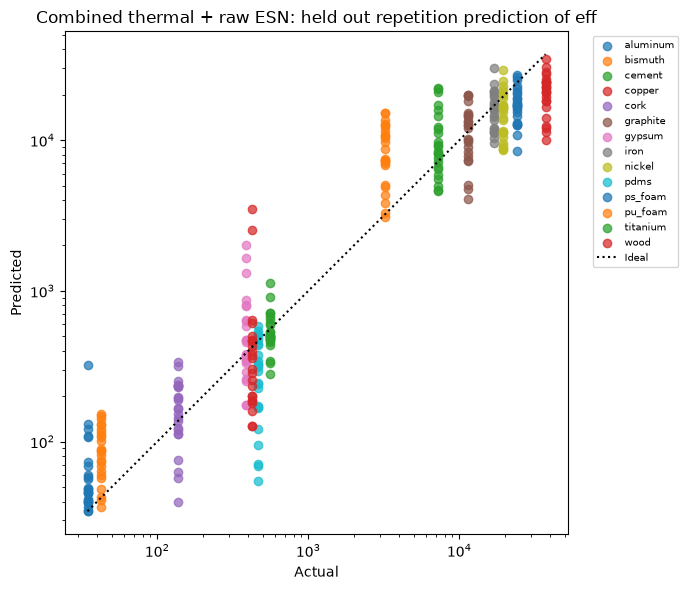

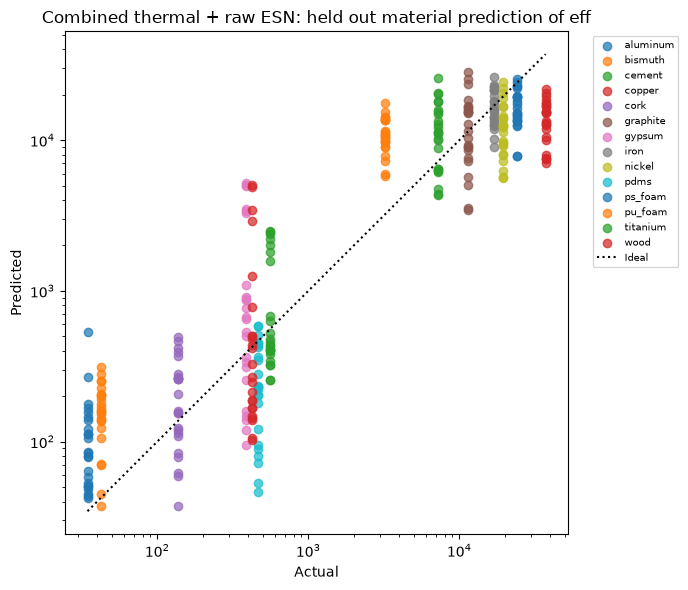

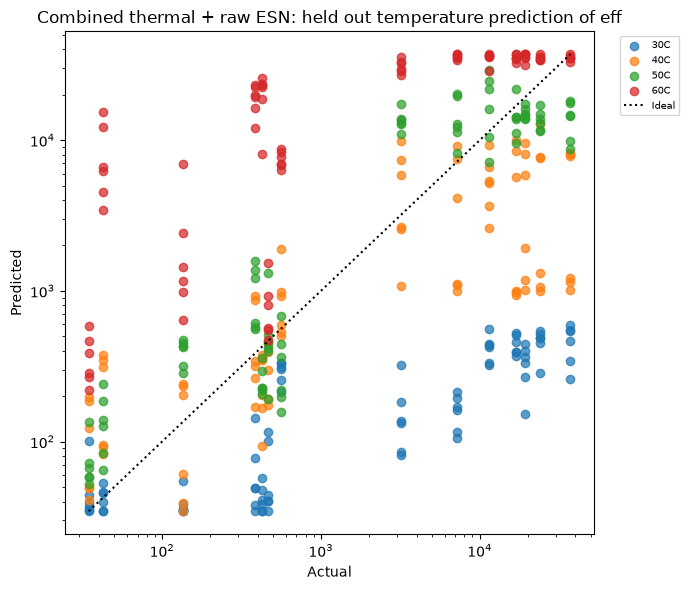

In [15]:
def plot_actual_predicted(predicted, title, color_column):
    shown = predicted[
        (predicted["y_true"] > 0) & (predicted["y_pred"] > 0)
    ].copy()
    if shown.empty:
        warnings.warn(f"No positive actual/predicted values to plot: {title}")
        return

    fig, ax = plt.subplots(figsize=(7, 6))
    for label, part in shown.groupby(color_column, sort=True):
        ax.scatter(
            part["y_true"], part["y_pred"],
            label=str(label), alpha=0.72,
        )
    low = min(shown["y_true"].min(), shown["y_pred"].min())
    high = max(shown["y_true"].max(), shown["y_pred"].max())
    ax.plot([low, high], [low, high], "k:", label="Ideal")
    ax.set(
        xscale="log", yscale="log",
        xlabel="Actual", ylabel="Predicted", title=title,
    )
    ax.legend(fontsize=7, bbox_to_anchor=(1.04, 1), loc="upper left")
    fig.tight_layout()
    plt.show()


for protocol in PROTOCOLS:
    color_column = "Temperature" if protocol == "held_out_temperature" else "Sample"
    for target in REGRESSION_TARGETS:
        plot_actual_predicted(
            predictions[(protocol, FEATURE_FAMILY, target)],
            f"Combined thermal + raw ESN: {protocol.replace('_', ' ')} prediction of {target}",
            color_column,
        )


# 11. Compare protocols


In [16]:
comparison = ALL_RESULTS.pivot_table(
    index=["feature_family", "target"], columns="protocol",
    values=["r2", "nrmse_range", "mae"],
)
display(comparison)


mae                      \
protocol                        held_out_material held_out_repetition   
feature_family           target                                         
combined_raw_esn_thermal eff          4595.672594         3396.834816   

                                                           nrmse_range  \
protocol                        held_out_temperature held_out_material   
feature_family           target                                          
combined_raw_esn_thermal eff              8286.66261          0.216828   

                                                                          \
protocol                        held_out_repetition held_out_temperature   
feature_family           target                                            
combined_raw_esn_thermal eff               0.166398             0.349711   

                                               r2                      \
protocol                        held_out_material held_out_repetition   
feature_family           target                                         
combined_raw_esn_thermal eff             0.483267            0.695678   

                                                      
protocol                        held_out_temperature  
feature_family           target                       
combined_raw_esn_thermal eff               -0.344166

# 12. Interpretation and provenance

- No hyperparameter optimization occurs in 4BBBB; settings come from 4AAAA.
- The regressor receives temperature, manual thermal features, and raw ESN states.
- The ESN input scaler is fitted independently inside every evaluation fold.
- Washout is zero and raw states cover the complete ordered 0–1 s window.
- Pooled LOMO measures prediction across all 336 out-of-fold trials.
- Per-material LOMO R² remains undefined because each material has one target;
  use fold RMSE, training-range NRMSE, bias, and material-averaged pooled R².
- LORO and LOTO are complementary diagnostics, not replacements for LOMO.
